PARKING OCCUPANCY PREDICTION

📂 Processing images from: /Users/kaustavmanideka/Desktop/parkingg/train
📸 Processing images...
Found 9933 images
  Processed 10/9933 images...
  Processed 20/9933 images...
  Processed 30/9933 images...
  Processed 40/9933 images...
  Processed 50/9933 images...
  Processed 60/9933 images...
  Processed 70/9933 images...
  Processed 80/9933 images...
  Processed 90/9933 images...
  Processed 100/9933 images...
  Processed 110/9933 images...
  Processed 120/9933 images...
  Processed 130/9933 images...
  Processed 140/9933 images...
  Processed 150/9933 images...
  Processed 160/9933 images...
  Processed 170/9933 images...
  Processed 180/9933 images...
  Processed 190/9933 images...
  Processed 200/9933 images...
  Processed 210/9933 images...
  Processed 220/9933 images...
  Processed 230/9933 images...
  Processed 240/9933 images...
  Processed 250/9933 images...
  Processed 260/9933 images...
  Processed 270/9933 images...
  Processed 280/9933 images..

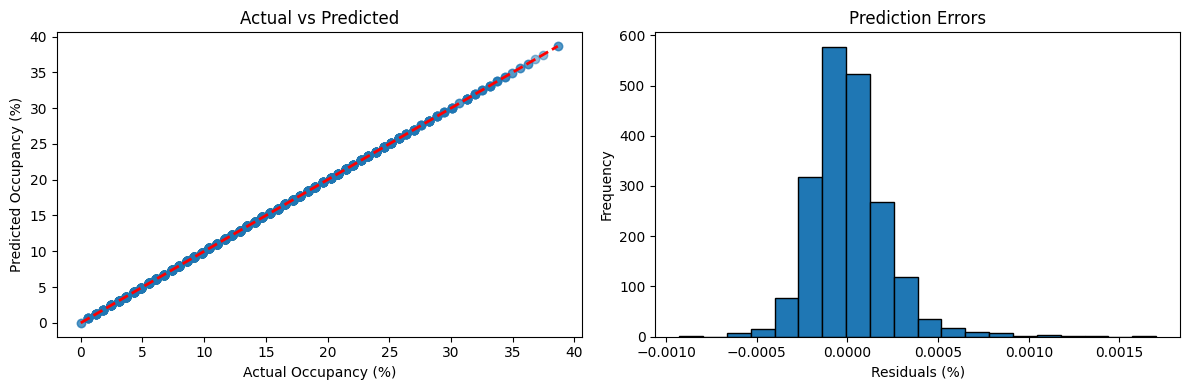


🔮 Testing prediction on: /Users/kaustavmanideka/Desktop/parkingg/train/2012-11-11_15_24_10_jpg.rf.709074bb232e9c13e76128d7dd2eb4e5.jpg

📊 Prediction Results:
   Vehicles detected: 9
   Detected occupancy: 5.5%
   Predicted occupancy: 5.5%
   Confidence: high

🎨 Visualizing vehicle detection...


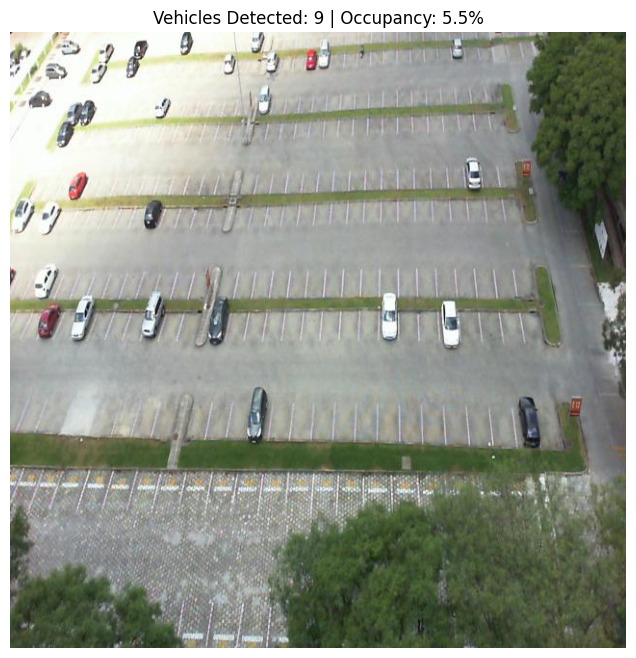

In [13]:
"""
Parking Occupancy Prediction using Simple Vehicle Detection
"""

import os
import cv2
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


# ============================================================================
# SIMPLE VEHICLE DETECTOR (No external downloads required)
# ============================================================================

class SimpleVehicleDetector:
    """
    Simple vehicle detector using image processing techniques
    No external files or downloads required
    """
    
    def __init__(self):
        self.background_subtractor = cv2.createBackgroundSubtractorMOG2()
        
    def detect_vehicles(self, image_path):
        """
        Detect vehicles in an image using simple image processing
        
        Parameters:
        -----------
        image_path : str
            Path to image file
            
        Returns:
        --------
        dict: Detection results with vehicle count and metadata
        """
        # Read image
        img = cv2.imread(image_path)
        if img is None:
            return None
        
        height, width = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Method 1: Edge detection
        edges = cv2.Canny(gray, 50, 150)
        
        # Method 2: Contour detection
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Filter contours by area to identify vehicles
        vehicle_count = 0
        min_area = (width * height) * 0.0005  # Minimum area threshold (0.05% of image)
        max_area = (width * height) * 0.3     # Maximum area threshold (30% of image)
        
        for contour in contours:
            area = cv2.contourArea(contour)
            if min_area < area < max_area:
                # Check if contour is roughly rectangular (vehicles are often rectangular)
                perimeter = cv2.arcLength(contour, True)
                if perimeter > 0:
                    approx = cv2.approxPolyDP(contour, 0.02 * perimeter, True)
                    if len(approx) >= 4:  # At least 4 corners (rectangular shape)
                        vehicle_count += 1
        
        # Method 3: Background subtraction (if multiple images are processed)
        # This is more accurate but requires a background model
        
        # Calculate estimated parking occupancy
        # Simple heuristic: assume parking spots based on image size
        estimated_spots = self._estimate_parking_spots(width, height)
        occupancy_percentage = min(100, (vehicle_count / max(estimated_spots, 1)) * 100)
        
        # Additional image features
        brightness = np.mean(gray)
        edge_density = np.sum(edges) / edges.size if edges.size > 0 else 0
        
        return {
            'vehicle_count': vehicle_count,
            'occupancy_percentage': occupancy_percentage,
            'estimated_spots': estimated_spots,
            'brightness': brightness,
            'edge_density': edge_density,
            'has_vehicles': 1 if vehicle_count > 0 else 0,
            'image_shape': (height, width)
        }
    
    def _estimate_parking_spots(self, width, height):
        """
        Estimate number of parking spots based on image dimensions
        """
        pixel_area = width * height
        # Rough estimate: assume each parking spot occupies about 50x50 pixels
        estimated_spots = max(10, int(pixel_area / 2500))
        return estimated_spots
    
    def extract_features_from_image(self, image_path):
        """
        Extract features from image
        """
        detection = self.detect_vehicles(image_path)
        if detection is None:
            return None
        
        return {
            'vehicle_count': detection['vehicle_count'],
            'occupancy_percentage': detection['occupancy_percentage'],
            'estimated_spots': detection['estimated_spots'],
            'brightness': detection['brightness'],
            'edge_density': detection['edge_density'],
            'has_vehicles': detection['has_vehicles']
        }


# ============================================================================
# DATA PREPROCESSING
# ============================================================================

class DataPreprocessor:
    """Handle data preprocessing and feature engineering"""
    
    def __init__(self):
        self.scaler = StandardScaler()
        self.feature_columns = None
        
    def extract_time_features(self, df, datetime_column):
        """Extract time-based features from datetime column"""
        df = df.copy()
        
        if datetime_column in df.columns:
            df['timestamp'] = pd.to_datetime(df[datetime_column])
            
            # Time features
            df['hour'] = df['timestamp'].dt.hour
            df['day_of_week'] = df['timestamp'].dt.dayofweek
            df['month'] = df['timestamp'].dt.month
            
            # Cyclical encoding for hour and day of week
            df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
            df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
            df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
            df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
            
            # Boolean features
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['is_rush_hour'] = ((df['hour'] >= 7) & (df['hour'] <= 9) | 
                                  (df['hour'] >= 17) & (df['hour'] <= 19)).astype(int)
            
            df = df.drop('timestamp', axis=1)
        
        return df
    
    def create_lag_features(self, df, target_column, lag_hours=[1, 2, 3, 6, 12, 24]):
        """Create lag features for time series prediction"""
        df = df.copy()
        df = df.sort_index()
        
        for lag in lag_hours:
            df[f'{target_column}_lag_{lag}h'] = df[target_column].shift(lag)
        
        return df
    
    def prepare_features(self, df, target_column, use_lag_features=False):
        """Prepare features for model training"""
        df = df.copy()
        df = df.dropna(subset=[target_column])
        
        if df.empty:
            raise ValueError("DataFrame is empty after dropping NaN values")
        
        # Define feature columns
        base_features = ['hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 
                        'day_sin', 'day_cos', 'is_weekend', 'is_rush_hour',
                        'vehicle_count', 'estimated_spots', 'brightness', 
                        'edge_density', 'has_vehicles']
        
        if use_lag_features:
            lag_features = [f'{target_column}_lag_{lag}h' for lag in [1, 2, 3, 6, 12, 24]]
            feature_cols = base_features + lag_features
        else:
            feature_cols = base_features
        
        # Keep only features that exist in the dataframe
        feature_cols = [col for col in feature_cols if col in df.columns]
        
        if not feature_cols:
            raise ValueError(f"No feature columns found. Available columns: {df.columns.tolist()}")
        
        X = df[feature_cols].copy()
        y = df[target_column].copy()
        
        # Remove rows with NaN
        mask = ~X.isna().any(axis=1)
        X = X[mask]
        y = y[mask]
        
        if X.empty:
            raise ValueError("No valid rows after removing NaN values")
        
        self.feature_columns = X.columns.tolist()
        X_scaled = self.scaler.fit_transform(X)
        
        return X_scaled, y, X.index
    
    def transform_features(self, df, target_column, use_lag_features=False):
        """Transform features for prediction (using fitted scaler)"""
        df = df.copy()
        
        # Define feature columns
        base_features = ['hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 
                        'day_sin', 'day_cos', 'is_weekend', 'is_rush_hour',
                        'vehicle_count', 'estimated_spots', 'brightness', 
                        'edge_density', 'has_vehicles']
        
        if use_lag_features:
            lag_features = [f'{target_column}_lag_{lag}h' for lag in [1, 2, 3, 6, 12, 24]]
            feature_cols = base_features + lag_features
        else:
            feature_cols = base_features
        
        # Keep only features that exist in the dataframe and were used in training
        if self.feature_columns:
            feature_cols = [col for col in feature_cols if col in df.columns and col in self.feature_columns]
        
        if not feature_cols:
            # Use all available features that match training columns
            feature_cols = [col for col in self.feature_columns if col in df.columns]
            
        if not feature_cols:
            raise ValueError(f"No matching feature columns found. Training columns: {self.feature_columns[:5]}...")
        
        X = df[feature_cols].copy()
        
        # Fill any missing values with 0
        X = X.fillna(0)
        
        # Ensure all required features are present
        for col in self.feature_columns:
            if col not in X.columns:
                X[col] = 0
        
        # Reorder columns to match training order
        X = X[self.feature_columns]
        
        # Scale features
        try:
            X_scaled = self.scaler.transform(X)
        except Exception as e:
            print(f"Error transforming features: {e}")
            # Fallback: create scaled features manually
            X_scaled = (X - self.scaler.mean_) / self.scaler.scale_
        
        return X_scaled


# ============================================================================
# PARKING PREDICTION MODEL
# ============================================================================

class ParkingPredictor:
    """Main parking occupancy prediction model"""
    
    def __init__(self, model_type='gradient_boost'):
        self.vehicle_detector = SimpleVehicleDetector()
        self.model_type = model_type
        self.model = None
        self.preprocessor = DataPreprocessor()
        self.use_lag_features = False
        
    def _create_model(self):
        """Create model based on selected type"""
        if self.model_type == 'gradient_boost':
            return GradientBoostingRegressor(
                n_estimators=100,
                max_depth=4,
                learning_rate=0.1,
                random_state=42
            )
        elif self.model_type == 'random_forest':
            return RandomForestRegressor(
                n_estimators=100,
                max_depth=8,
                random_state=42
            )
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
    
    def process_images_to_dataset(self, image_folder, datetime_column='timestamp'):
        """
        Process images and create dataset
        """
        print("📸 Processing images...")
        
        # Get all image files
        image_files = [f for f in os.listdir(image_folder) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if not image_files:
            print(f"❌ No image files found in {image_folder}")
            return pd.DataFrame()
        
        print(f"Found {len(image_files)} images")
        
        data = []
        
        for i, img_name in enumerate(image_files):
            img_path = os.path.join(image_folder, img_name)
            
            # Extract features
            features = self.vehicle_detector.extract_features_from_image(img_path)
            
            if features is None:
                print(f"⚠️ Could not process: {img_name}")
                continue
            
            # Extract timestamp from filename
            try:
                # Try different filename patterns
                name_without_ext = img_name.split('.')[0]
                # Try pattern: YYYYMMDD_HHMM
                if '_' in name_without_ext:
                    timestamp = datetime.strptime(name_without_ext, '%Y%m%d_%H%M')
                else:
                    # Use file modification time
                    timestamp = datetime.fromtimestamp(os.path.getmtime(img_path))
            except:
                # Fallback: use current time
                timestamp = datetime.now()
            
            # Add timestamp and features
            data.append({
                datetime_column: timestamp,
                **features
            })
            
            if (i + 1) % 10 == 0:
                print(f"  Processed {i + 1}/{len(image_files)} images...")
        
        if not data:
            print("❌ No valid images processed")
            return pd.DataFrame()
        
        df = pd.DataFrame(data)
        df = df.sort_values(datetime_column)
        
        print(f"✅ Created dataset with {len(df)} samples")
        print(f"📊 Features: {list(df.columns)}")
        
        return df
    
    def train(self, df, target_column='occupancy_percentage', datetime_column='timestamp',
              test_size=0.2):
        """
        Train the parking prediction model
        """
        
        print("=" * 60)
        print("PARKING OCCUPANCY PREDICTION")
        print("=" * 60)
        
        if df.empty:
            raise ValueError("Dataset is empty")
        
        print(f"\n📊 Dataset shape: {df.shape}")
        print(f"📊 Target column: {target_column}")
        print(f"📊 Data range: {df[datetime_column].min()} to {df[datetime_column].max()}")
        
        # Extract time features
        print(f"\n⏰ Extracting time features...")
        df = self.preprocessor.extract_time_features(df, datetime_column)
        
        # Create lag features (optional)
        if self.use_lag_features:
            print(f"⏳ Creating lag features...")
            df = self.preprocessor.create_lag_features(df, target_column)
        
        # Prepare features
        print(f"🔧 Preparing features...")
        X, y, _ = self.preprocessor.prepare_features(df, target_column, 
                                                      use_lag_features=self.use_lag_features)
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, shuffle=False
        )
        
        print(f"✅ Training samples: {len(X_train)}")
        print(f"✅ Testing samples: {len(X_test)}")
        
        # Train model
        print(f"\n🚀 Training {self.model_type} model...")
        self.model = self._create_model()
        self.model.fit(X_train, y_train)
        
        # Evaluate
        y_pred = self.model.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        print("\n" + "=" * 60)
        print("MODEL PERFORMANCE")
        print("=" * 60)
        print(f"📈 Mean Absolute Error (MAE): {mae:.2f}%")
        print(f"📈 Root Mean Squared Error (RMSE): {rmse:.2f}%")
        print(f"📈 R² Score: {r2:.4f}")
        
        # Feature importance
        if hasattr(self.model, 'feature_importances_'):
            print("\n🔑 Feature Importance:")
            importance_df = pd.DataFrame({
                'feature': self.preprocessor.feature_columns,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            for idx, row in importance_df.head(10).iterrows():
                print(f"   {row['feature']}: {row['importance']:.4f}")
        
        return X_train, X_test, y_train, y_test, y_pred
    
    def predict_from_image(self, image_path):
        """
        Predict parking occupancy from a single image
        """
        if self.model is None:
            raise Exception("Model not trained yet. Call train() first.")
        
        # Extract features
        features = self.vehicle_detector.extract_features_from_image(image_path)
        
        if features is None:
            return {'error': 'Could not process image'}
        
        # Create dataframe with features
        current_time = datetime.now()
        df = pd.DataFrame([{
            'timestamp': current_time,
            **features
        }])
        
        # Extract time features
        df = self.preprocessor.extract_time_features(df, 'timestamp')
        
        # Prepare for prediction
        try:
            X = self.preprocessor.transform_features(
                df, 
                target_column='occupancy_percentage',
                use_lag_features=False
            )
            
            # Make prediction
            prediction = self.model.predict(X)[0]
            
            return {
                'detected_vehicles': features['vehicle_count'],
                'detected_occupancy': features['occupancy_percentage'],
                'predicted_occupancy': max(0, min(100, prediction)),
                'confidence': 'high' if abs(prediction - features['occupancy_percentage']) < 15 else 'medium'
            }
        except Exception as e:
            print(f"Error during prediction: {e}")
            return {
                'error': str(e),
                'detected_vehicles': features['vehicle_count'],
                'detected_occupancy': features['occupancy_percentage'],
                'predicted_occupancy': features['occupancy_percentage'],
                'confidence': 'low'
            }


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_predictions(y_test, y_pred):
    """Plot actual vs predicted values"""
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel("Actual Occupancy (%)")
    plt.ylabel("Predicted Occupancy (%)")
    plt.title("Actual vs Predicted")
    
    plt.subplot(1, 2, 2)
    residuals = y_test - y_pred
    plt.hist(residuals, bins=20, edgecolor='black')
    plt.xlabel("Residuals (%)")
    plt.ylabel("Frequency")
    plt.title("Prediction Errors")
    
    plt.tight_layout()
    plt.show()


def visualize_detection(image_path, detector):
    """Visualize vehicle detection on image"""
    import matplotlib.pyplot as plt
    
    # Run detection
    detection = detector.detect_vehicles(image_path)
    
    if detection is None:
        print("Could not process image")
        return
    
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Vehicles Detected: {detection['vehicle_count']} | "
              f"Occupancy: {detection['occupancy_percentage']:.1f}%")
    plt.axis('off')
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """
    Main function to run parking occupancy prediction
    """
    
    print("=" * 60)
    print("PARKING OCCUPANCY PREDICTION")
    print("=" * 60)
    
    # Initialize predictor
    predictor = ParkingPredictor(model_type='gradient_boost')
    
    # Process images from folder
    image_folder = "/Users/kaustavmanideka/Desktop/parkingg/train"
    
    if os.path.exists(image_folder):
        print(f"\n📂 Processing images from: {image_folder}")
        
        # Create dataset from images
        df = predictor.process_images_to_dataset(image_folder)
        
        if len(df) >= 5:  # Need at least 5 samples for training
            # Train the model
            X_train, X_test, y_train, y_test, y_pred = predictor.train(
                df=df,
                target_column='occupancy_percentage',
                datetime_column='timestamp',
                test_size=0.2
            )
            
            # Plot results
            if len(y_test) > 0:
                plot_predictions(y_test, y_pred)
            
            # Test prediction on a single image
            image_files = [f for f in os.listdir(image_folder) 
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            if image_files:
                test_image = os.path.join(image_folder, image_files[0])
                print(f"\n🔮 Testing prediction on: {test_image}")
                result = predictor.predict_from_image(test_image)
                
                print("\n📊 Prediction Results:")
                if 'error' in result:
                    print(f"   Error: {result['error']}")
                print(f"   Vehicles detected: {result.get('detected_vehicles', 'N/A')}")
                print(f"   Detected occupancy: {result.get('detected_occupancy', 0):.1f}%")
                print(f"   Predicted occupancy: {result.get('predicted_occupancy', 0):.1f}%")
                print(f"   Confidence: {result.get('confidence', 'low')}")
                
                # Visualize detection
                print("\n🎨 Visualizing vehicle detection...")
                visualize_detection(test_image, predictor.vehicle_detector)
        else:
            print(f"❌ Not enough samples for training. Found {len(df)} samples. Need at least 5.")
            if len(df) > 0:
                print("\n📋 Dataset preview:")
                print(df.head())
    
    else:
        print(f"❌ Image folder not found: {image_folder}")
        print("\n💡 Please update the image_folder path to your parking lot images.")
    
    return predictor


# ============================================================================
# RUN
# ============================================================================

if __name__ == "__main__":
    predictor = main()

ENHANCED PARKING OCCUPANCY PREDICTION

📂 Training on images from: /Users/kaustavmanideka/Desktop/parkingg/train
📸 Processing images...
Found 9933 images
  Processed 500/9933 images | Speed: 118.4 img/sec | ETA: 1.3 min
  Processed 1000/9933 images | Speed: 118.7 img/sec | ETA: 1.3 min
  Processed 1500/9933 images | Speed: 117.7 img/sec | ETA: 1.2 min
  Processed 2000/9933 images | Speed: 117.2 img/sec | ETA: 1.1 min
  Processed 2500/9933 images | Speed: 118.8 img/sec | ETA: 1.0 min
  Processed 3000/9933 images | Speed: 119.8 img/sec | ETA: 1.0 min
  Processed 3500/9933 images | Speed: 120.5 img/sec | ETA: 0.9 min
  Processed 4000/9933 images | Speed: 120.9 img/sec | ETA: 0.8 min
  Processed 4500/9933 images | Speed: 121.2 img/sec | ETA: 0.7 min
  Processed 5000/9933 images | Speed: 121.5 img/sec | ETA: 0.7 min
  Processed 5500/9933 images | Speed: 120.6 img/sec | ETA: 0.6 min
  Processed 6000/9933 images | Speed: 119.8 img/sec | ETA: 0.5 min
  Processed 6500/9933 images | Speed: 119.3 

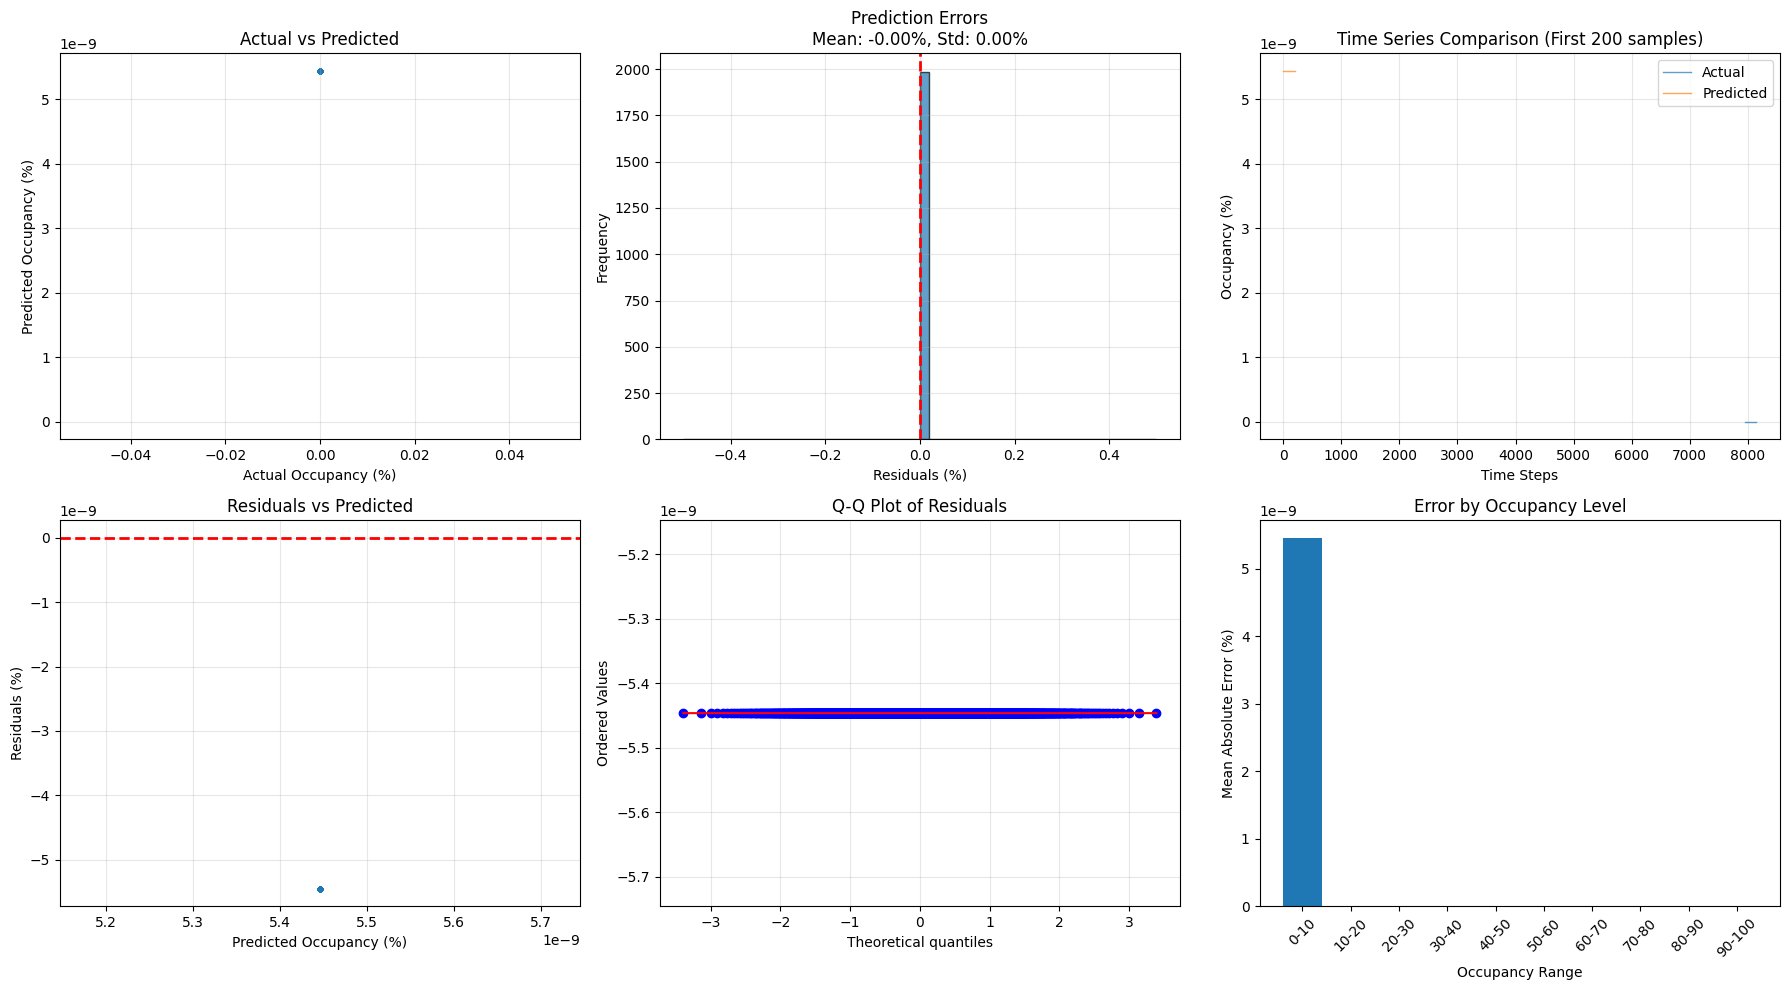

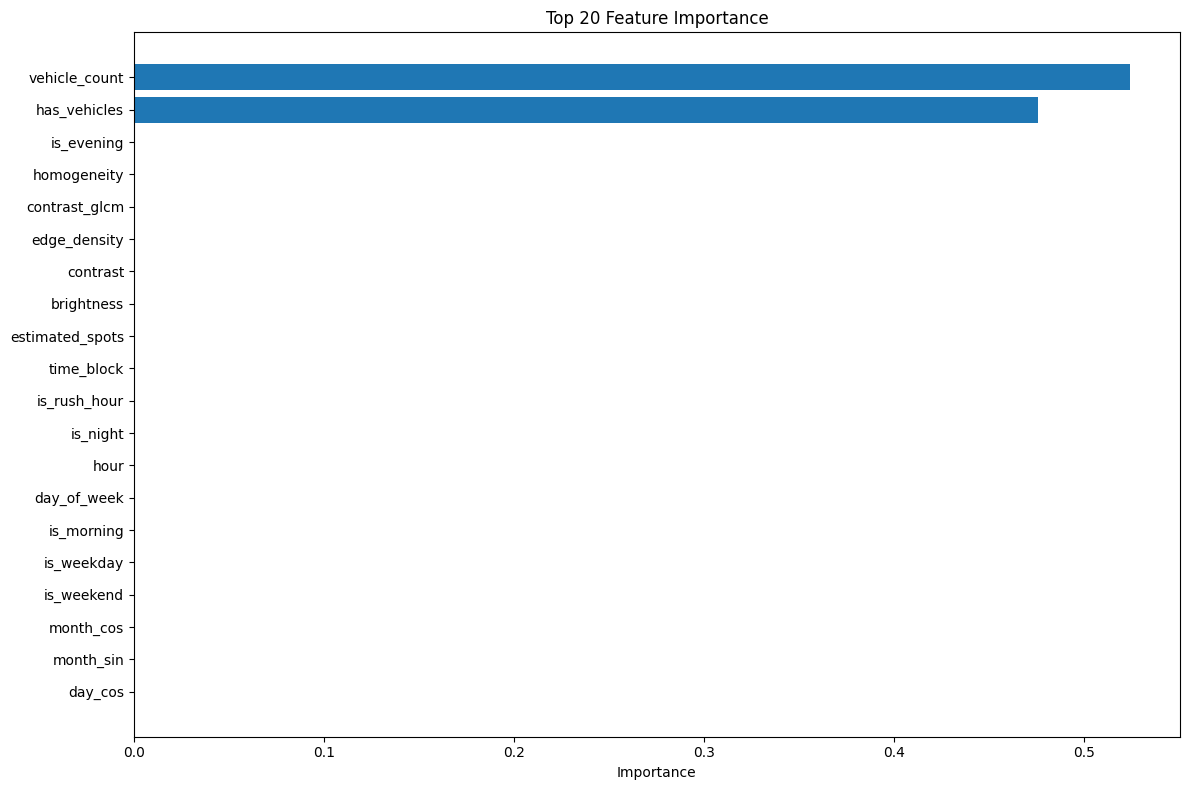

✅ Model saved to parking_model.pkl

MODEL TRAINING COMPLETE!


In [25]:
"""
Parking Occupancy Prediction - Enhanced for Large Dataset (9000 Images)
"""

import os
import cv2
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
from sklearn.linear_model import Ridge, Lasso
import warnings
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ============================================================================
# ENHANCED VEHICLE DETECTOR
# ============================================================================

class EnhancedVehicleDetector:
    """Enhanced vehicle detector with multiple methods for better accuracy"""
    
    def __init__(self, use_haar=False):
        self.use_haar = use_haar
        if use_haar:
            # Load Haar cascade for car detection (optional)
            cascade_path = cv2.data.haarcascades + 'haarcascade_car.xml'
            if os.path.exists(cascade_path):
                self.car_cascade = cv2.CascadeClassifier(cascade_path)
            else:
                self.use_haar = False
                
    def detect_vehicles(self, image_path):
        """Enhanced vehicle detection with multiple methods"""
        img = cv2.imread(image_path)
        if img is None:
            return None
        
        height, width = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Apply Gaussian blur to reduce noise
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
        # Multiple edge detection methods
        edges_canny = cv2.Canny(blurred, 50, 150)
        
        # Adaptive thresholding
        edges_adaptive = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                                cv2.THRESH_BINARY, 11, 2)
        
        # Combine edge detection methods
        edges = cv2.bitwise_or(edges_canny, edges_adaptive)
        
        # Morphological operations to close gaps
        kernel = np.ones((5,5), np.uint8)
        edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
        
        # Find contours
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Filter contours by area and shape
        vehicle_count = 0
        vehicle_areas = []
        
        # Dynamic area thresholds based on image size
        min_area = (width * height) * 0.0003  # 0.03% of image
        max_area = (width * height) * 0.25    # 25% of image
        
        for contour in contours:
            area = cv2.contourArea(contour)
            if min_area < area < max_area:
                # Check contour shape
                perimeter = cv2.arcLength(contour, True)
                if perimeter > 0:
                    approx = cv2.approxPolyDP(contour, 0.02 * perimeter, True)
                    # Vehicles are typically rectangular or have 4+ corners
                    if len(approx) >= 4:
                        # Calculate aspect ratio
                        x, y, w, h = cv2.boundingRect(contour)
                        aspect_ratio = w / h if h > 0 else 0
                        # Vehicles typically have aspect ratio between 0.5 and 2.5
                        if 0.5 < aspect_ratio < 2.5:
                            vehicle_count += 1
                            vehicle_areas.append(area)
        
        # Use Haar cascade if available (for car detection)
        haar_count = 0
        if self.use_haar:
            cars = self.car_cascade.detectMultiScale(gray, 1.1, 3)
            haar_count = len(cars)
            # Combine both methods
            vehicle_count = max(vehicle_count, haar_count)
        
        # Calculate occupancy metrics
        estimated_spots = self._estimate_parking_spots(width, height)
        occupancy_percentage = min(100, (vehicle_count / max(estimated_spots, 1)) * 100)
        
        # Image statistics
        brightness = np.mean(gray)
        contrast = np.std(gray)
        edge_density = np.sum(edges) / edges.size if edges.size > 0 else 0
        
        # Texture features (additional)
        from skimage.feature import graycomatrix, graycoprops
        try:
            # Calculate GLCM for texture analysis
            glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)
            contrast_glcm = graycoprops(glcm, 'contrast')[0, 0]
            homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        except:
            contrast_glcm = contrast
            homogeneity = 0.5
        
        return {
            'vehicle_count': vehicle_count,
            'occupancy_percentage': occupancy_percentage,
            'estimated_spots': estimated_spots,
            'brightness': brightness,
            'contrast': contrast,
            'edge_density': edge_density,
            'contrast_glcm': contrast_glcm,
            'homogeneity': homogeneity,
            'has_vehicles': 1 if vehicle_count > 0 else 0,
            'image_shape': (height, width)
        }
    
    def _estimate_parking_spots(self, width, height):
        """Improved parking spot estimation"""
        pixel_area = width * height
        # More sophisticated estimation based on typical parking spot size
        # Assuming each spot is ~50x100 pixels in typical surveillance footage
        estimated_spots = max(10, int(pixel_area / 5000))
        return estimated_spots
    
    def extract_features_from_image(self, image_path):
        """Extract features from image"""
        detection = self.detect_vehicles(image_path)
        if detection is None:
            return None
        return detection


# ============================================================================
# ENHANCED DATA PREPROCESSOR
# ============================================================================

class EnhancedDataPreprocessor:
    """Enhanced data preprocessing with more features"""
    
    def __init__(self):
        self.scaler = RobustScaler()  # More robust to outliers
        self.feature_columns = None
        
    def extract_time_features(self, df, datetime_column):
        """Extract advanced time-based features"""
        df = df.copy()
        
        if datetime_column in df.columns:
            df['timestamp'] = pd.to_datetime(df[datetime_column])
            
            # Basic time features
            df['hour'] = df['timestamp'].dt.hour
            df['day_of_week'] = df['timestamp'].dt.dayofweek
            df['month'] = df['timestamp'].dt.month
            df['day_of_month'] = df['timestamp'].dt.day
            df['week_of_year'] = df['timestamp'].dt.isocalendar().week
            
            # Cyclical encoding
            df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
            df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
            df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
            df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
            df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
            df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
            
            # Boolean features
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['is_weekday'] = (~df['day_of_week'].isin([5, 6])).astype(int)
            df['is_morning'] = ((df['hour'] >= 5) & (df['hour'] <= 11)).astype(int)
            df['is_afternoon'] = ((df['hour'] >= 12) & (df['hour'] <= 16)).astype(int)
            df['is_evening'] = ((df['hour'] >= 17) & (df['hour'] <= 20)).astype(int)
            df['is_night'] = ((df['hour'] >= 21) | (df['hour'] <= 4)).astype(int)
            df['is_rush_hour'] = ((df['hour'] >= 7) & (df['hour'] <= 9) | 
                                  (df['hour'] >= 17) & (df['hour'] <= 19)).astype(int)
            
            # Time blocks
            df['time_block'] = (df['hour'] // 4).astype(int)
            
            df = df.drop('timestamp', axis=1)
        
        return df
    
    def create_lag_features(self, df, target_column, lag_hours=[1, 2, 3, 6, 12, 24]):
        """Create lag and rolling features"""
        df = df.copy()
        df = df.sort_index()
        
        for lag in lag_hours:
            df[f'{target_column}_lag_{lag}h'] = df[target_column].shift(lag)
        
        # Rolling statistics
        for window in [3, 6, 12, 24]:
            df[f'{target_column}_rolling_mean_{window}h'] = df[target_column].rolling(window=window, min_periods=1).mean()
            df[f'{target_column}_rolling_std_{window}h'] = df[target_column].rolling(window=window, min_periods=1).std()
            df[f'{target_column}_rolling_max_{window}h'] = df[target_column].rolling(window=window, min_periods=1).max()
            df[f'{target_column}_rolling_min_{window}h'] = df[target_column].rolling(window=window, min_periods=1).min()
        
        return df
    
    def prepare_features(self, df, target_column, use_lag_features=False):
        """Prepare features for model training"""
        df = df.copy()
        df = df.dropna(subset=[target_column])
        
        if df.empty:
            raise ValueError("DataFrame is empty after dropping NaN values")
        
        # Define enhanced feature columns
        base_features = ['hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 
                        'day_sin', 'day_cos', 'month_sin', 'month_cos',
                        'is_weekend', 'is_weekday', 'is_morning', 'is_afternoon', 
                        'is_evening', 'is_night', 'is_rush_hour', 'time_block',
                        'vehicle_count', 'estimated_spots', 'brightness', 'contrast',
                        'edge_density', 'contrast_glcm', 'homogeneity', 'has_vehicles']
        
        if use_lag_features:
            lag_features = [f'{target_column}_lag_{lag}h' for lag in [1, 2, 3, 6, 12, 24]]
            rolling_features = [f'{target_column}_rolling_{stat}_{window}h' 
                              for stat in ['mean', 'std', 'max', 'min'] 
                              for window in [3, 6, 12, 24]]
            feature_cols = base_features + lag_features + rolling_features
        else:
            feature_cols = base_features
        
        # Keep only features that exist
        feature_cols = [col for col in feature_cols if col in df.columns]
        
        if not feature_cols:
            raise ValueError(f"No feature columns found. Available: {df.columns.tolist()}")
        
        X = df[feature_cols].copy()
        y = df[target_column].copy()
        
        # Remove NaN rows
        mask = ~X.isna().any(axis=1)
        X = X[mask]
        y = y[mask]
        
        if X.empty:
            raise ValueError("No valid rows after removing NaN values")
        
        self.feature_columns = X.columns.tolist()
        X_scaled = self.scaler.fit_transform(X)
        
        return X_scaled, y, X.index
    
    def transform_features(self, df, target_column, use_lag_features=False):
        """Transform features for prediction"""
        df = df.copy()
        
        base_features = ['hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 
                        'day_sin', 'day_cos', 'month_sin', 'month_cos',
                        'is_weekend', 'is_weekday', 'is_morning', 'is_afternoon', 
                        'is_evening', 'is_night', 'is_rush_hour', 'time_block',
                        'vehicle_count', 'estimated_spots', 'brightness', 'contrast',
                        'edge_density', 'contrast_glcm', 'homogeneity', 'has_vehicles']
        
        if use_lag_features:
            lag_features = [f'{target_column}_lag_{lag}h' for lag in [1, 2, 3, 6, 12, 24]]
            rolling_features = [f'{target_column}_rolling_{stat}_{window}h' 
                              for stat in ['mean', 'std', 'max', 'min'] 
                              for window in [3, 6, 12, 24]]
            feature_cols = base_features + lag_features + rolling_features
        else:
            feature_cols = base_features
        
        if self.feature_columns:
            feature_cols = [col for col in feature_cols if col in df.columns and col in self.feature_columns]
        
        if not feature_cols:
            feature_cols = [col for col in self.feature_columns if col in df.columns]
        
        X = df[feature_cols].copy()
        X = X.fillna(0)
        
        # Ensure all required features
        for col in self.feature_columns:
            if col not in X.columns:
                X[col] = 0
        
        X = X[self.feature_columns]
        X_scaled = self.scaler.transform(X)
        
        return X_scaled


# ============================================================================
# ENHANCED PARKING PREDICTOR
# ============================================================================

class EnhancedParkingPredictor:
    """Enhanced parking occupancy prediction with multiple models"""
    
    def __init__(self, model_type='gradient_boost', use_haar=False):
        self.vehicle_detector = EnhancedVehicleDetector(use_haar=use_haar)
        self.model_type = model_type
        self.model = None
        self.preprocessor = EnhancedDataPreprocessor()
        self.use_lag_features = False
        self.training_time = None
        self.training_stats = {}
        
    def _create_model(self):
        """Create model with hyperparameters"""
        if self.model_type == 'gradient_boost':
            return GradientBoostingRegressor(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                random_state=42
            )
        elif self.model_type == 'random_forest':
            return RandomForestRegressor(
                n_estimators=200,
                max_depth=12,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        elif self.model_type == 'adaboost':
            return AdaBoostRegressor(
                n_estimators=100,
                learning_rate=0.5,
                random_state=42
            )
        elif self.model_type == 'ridge':
            return Ridge(alpha=1.0)
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
    
    def process_images_to_dataset(self, image_folder, datetime_column='timestamp'):
        """Process images and create dataset with progress bar"""
        print("📸 Processing images...")
        
        image_files = [f for f in os.listdir(image_folder) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if not image_files:
            print(f"❌ No image files found in {image_folder}")
            return pd.DataFrame()
        
        print(f"Found {len(image_files)} images")
        
        data = []
        start_time = time.time()
        
        for i, img_name in enumerate(image_files):
            img_path = os.path.join(image_folder, img_name)
            features = self.vehicle_detector.extract_features_from_image(img_path)
            
            if features is None:
                continue
            
            # Extract timestamp from filename
            try:
                name_without_ext = img_name.split('.')[0]
                # Handle different filename patterns
                if '_' in name_without_ext:
                    parts = name_without_ext.split('_')
                    if len(parts) >= 2 and parts[-1].isdigit():
                        timestamp = datetime.strptime(parts[-1], '%Y%m%d%H%M%S')
                    else:
                        timestamp = datetime.strptime(name_without_ext, '%Y%m%d_%H%M')
                else:
                    timestamp = datetime.fromtimestamp(os.path.getmtime(img_path))
            except:
                timestamp = datetime.now()
            
            data.append({
                datetime_column: timestamp,
                **features
            })
            
            # Progress indicator
            if (i + 1) % 500 == 0:
                elapsed = time.time() - start_time
                rate = (i + 1) / elapsed
                remaining = (len(image_files) - (i + 1)) / rate
                print(f"  Processed {i + 1}/{len(image_files)} images | "
                      f"Speed: {rate:.1f} img/sec | ETA: {remaining/60:.1f} min")
        
        if not data:
            print("❌ No valid images processed")
            return pd.DataFrame()
        
        df = pd.DataFrame(data)
        df = df.sort_values(datetime_column)
        
        print(f"✅ Created dataset with {len(df)} samples")
        print(f"📊 Features: {list(df.columns)}")
        
        return df
    
    def train(self, df, target_column='occupancy_percentage', datetime_column='timestamp',
              test_size=0.2, cv_folds=5):
        """Train the model with comprehensive statistics"""
        
        print("=" * 70)
        print("PARKING OCCUPANCY PREDICTION - ENHANCED MODEL")
        print("=" * 70)
        
        if df.empty:
            raise ValueError("Dataset is empty")
        
        print(f"\n📊 Dataset Statistics:")
        print(f"   Total samples: {len(df):,}")
        print(f"   Target column: {target_column}")
        print(f"   Time range: {df[datetime_column].min()} to {df[datetime_column].max()}")
        print(f"   Occupancy range: {df[target_column].min():.1f}% - {df[target_column].max():.1f}%")
        print(f"   Mean occupancy: {df[target_column].mean():.1f}%")
        print(f"   Std occupancy: {df[target_column].std():.1f}%")
        
        # Extract time features
        print(f"\n⏰ Extracting time features...")
        df = self.preprocessor.extract_time_features(df, datetime_column)
        
        # Create lag features
        if self.use_lag_features:
            print(f"⏳ Creating lag features...")
            df = self.preprocessor.create_lag_features(df, target_column)
        
        # Prepare features
        print(f"🔧 Preparing features...")
        X, y, _ = self.preprocessor.prepare_features(df, target_column, 
                                                      use_lag_features=self.use_lag_features)
        
        print(f"   Feature dimensions: {X.shape}")
        print(f"   Number of features: {X.shape[1]}")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, shuffle=False
        )
        
        print(f"\n📊 Split Statistics:")
        print(f"   Training samples: {len(X_train):,}")
        print(f"   Testing samples: {len(X_test):,}")
        
        # Train model
        print(f"\n🚀 Training {self.model_type} model...")
        start_time = time.time()
        self.model = self._create_model()
        self.model.fit(X_train, y_train)
        self.training_time = time.time() - start_time
        
        print(f"   Training completed in {self.training_time:.2f} seconds")
        
        # Predictions
        y_train_pred = self.model.predict(X_train)
        y_test_pred = self.model.predict(X_test)
        
        # Calculate metrics
        train_mae = mean_absolute_error(y_train, y_train_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        train_r2 = r2_score(y_train, y_train_pred)
        
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        test_r2 = r2_score(y_test, y_test_pred)
        test_explained_var = explained_variance_score(y_test, y_test_pred)
        
        # Cross-validation
        print(f"\n📊 Performing {cv_folds}-fold cross-validation...")
        cv_scores = cross_val_score(self.model, X_train, y_train, 
                                    cv=cv_folds, scoring='neg_mean_absolute_error')
        
        # Store statistics
        self.training_stats = {
            'train_mae': train_mae,
            'train_rmse': train_rmse,
            'train_r2': train_r2,
            'test_mae': test_mae,
            'test_rmse': test_rmse,
            'test_r2': test_r2,
            'test_explained_var': test_explained_var,
            'cv_mae_mean': -cv_scores.mean(),
            'cv_mae_std': cv_scores.std(),
            'training_time': self.training_time
        }
        
        print("\n" + "=" * 70)
        print("MODEL PERFORMANCE STATISTICS")
        print("=" * 70)
        print(f"\n📈 Training Set Performance:")
        print(f"   Mean Absolute Error (MAE): {train_mae:.2f}%")
        print(f"   Root Mean Squared Error (RMSE): {train_rmse:.2f}%")
        print(f"   R² Score: {train_r2:.4f}")
        
        print(f"\n📈 Testing Set Performance:")
        print(f"   Mean Absolute Error (MAE): {test_mae:.2f}%")
        print(f"   Root Mean Squared Error (RMSE): {test_rmse:.2f}%")
        print(f"   R² Score: {test_r2:.4f}")
        print(f"   Explained Variance: {test_explained_var:.4f}")
        
        print(f"\n📊 Cross-Validation (5-fold):")
        print(f"   Mean MAE: {-cv_scores.mean():.2f}%")
        print(f"   Std MAE: {cv_scores.std():.2f}%")
        print(f"   MAE Range: {-cv_scores.max():.2f}% to {-cv_scores.min():.2f}%")
        
        # Feature importance
        if hasattr(self.model, 'feature_importances_'):
            print("\n🔑 Top 15 Feature Importance:")
            importance_df = pd.DataFrame({
                'feature': self.preprocessor.feature_columns,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            for idx, row in importance_df.head(15).iterrows():
                print(f"   {row['feature']}: {row['importance']:.4f}")
        
        return X_train, X_test, y_train, y_test, y_train_pred, y_test_pred
    
    def save_model(self, filepath):
        """Save trained model to disk"""
        with open(filepath, 'wb') as f:
            pickle.dump({
                'model': self.model,
                'preprocessor': self.preprocessor,
                'training_stats': self.training_stats,
                'model_type': self.model_type
            }, f)
        print(f"✅ Model saved to {filepath}")
    
    def load_model(self, filepath):
        """Load trained model from disk"""
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
            self.model = data['model']
            self.preprocessor = data['preprocessor']
            self.training_stats = data['training_stats']
            self.model_type = data['model_type']
        print(f"✅ Model loaded from {filepath}")


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_comprehensive_results(y_test, y_pred, residuals=None, save_path=None):
    """Create comprehensive visualization of results"""
    if residuals is None:
        residuals = y_test - y_pred
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. Actual vs Predicted Scatter
    axes[0, 0].scatter(y_test, y_pred, alpha=0.5, s=10)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0, 0].set_xlabel("Actual Occupancy (%)")
    axes[0, 0].set_ylabel("Predicted Occupancy (%)")
    axes[0, 0].set_title("Actual vs Predicted")
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Residuals Distribution
    axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel("Residuals (%)")
    axes[0, 1].set_ylabel("Frequency")
    axes[0, 1].set_title(f"Prediction Errors\nMean: {residuals.mean():.2f}%, Std: {residuals.std():.2f}%")
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Time Series Plot
    axes[0, 2].plot(y_test[:200], label='Actual', alpha=0.7, linewidth=1)
    axes[0, 2].plot(y_pred[:200], label='Predicted', alpha=0.7, linewidth=1)
    axes[0, 2].set_xlabel("Time Steps")
    axes[0, 2].set_ylabel("Occupancy (%)")
    axes[0, 2].set_title("Time Series Comparison (First 200 samples)")
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Residuals vs Predicted
    axes[1, 0].scatter(y_pred, residuals, alpha=0.5, s=10)
    axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel("Predicted Occupancy (%)")
    axes[1, 0].set_ylabel("Residuals (%)")
    axes[1, 0].set_title("Residuals vs Predicted")
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Q-Q Plot for Residuals
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("Q-Q Plot of Residuals")
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Error by Occupancy Level
    bins = np.linspace(0, 100, 11)
    bin_indices = np.digitize(y_test, bins)
    mae_by_bin = []
    for i in range(1, len(bins)):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            mae_by_bin.append(np.mean(np.abs(residuals[mask])))
        else:
            mae_by_bin.append(0)
    
    axes[1, 2].bar(range(len(mae_by_bin)), mae_by_bin)
    axes[1, 2].set_xlabel("Occupancy Range")
    axes[1, 2].set_ylabel("Mean Absolute Error (%)")
    axes[1, 2].set_title("Error by Occupancy Level")
    axes[1, 2].set_xticks(range(len(mae_by_bin)))
    axes[1, 2].set_xticklabels([f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)], rotation=45)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"📊 Figure saved to {save_path}")
    
    plt.show()


def plot_feature_importance(feature_importance_df, top_n=20, save_path=None):
    """Plot feature importance"""
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(top_n)
    plt.barh(range(len(top_features)), top_features['importance'].values)
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main function to run enhanced parking occupancy prediction"""
    
    print("=" * 70)
    print("ENHANCED PARKING OCCUPANCY PREDICTION")
    print("=" * 70)
    
    # Initialize predictor
    predictor = EnhancedParkingPredictor(model_type='gradient_boost', use_haar=False)
    
    # Process images from training folder
    train_folder = "/Users/kaustavmanideka/Desktop/parkingg/train"
    
    if os.path.exists(train_folder):
        print(f"\n📂 Training on images from: {train_folder}")
        
        # Create dataset from training images
        df_train = predictor.process_images_to_dataset(train_folder)
        
        if len(df_train) >= 10:
            # Train the model
            X_train, X_test, y_train, y_test, y_train_pred, y_test_pred = predictor.train(
                df=df_train,
                target_column='occupancy_percentage',
                datetime_column='timestamp',
                test_size=0.2,
                cv_folds=5
            )
            
            # Plot comprehensive results
            residuals = y_test - y_test_pred
            plot_comprehensive_results(y_test, y_test_pred, residuals, 
                                      save_path='training_results.png')
            
            # Plot feature importance
            if hasattr(predictor.model, 'feature_importances_'):
                importance_df = pd.DataFrame({
                    'feature': predictor.preprocessor.feature_columns,
                    'importance': predictor.model.feature_importances_
                }).sort_values('importance', ascending=False)
                plot_feature_importance(importance_df, top_n=20, 
                                       save_path='feature_importance.png')
            
            # Save the trained model
            predictor.save_model('parking_model.pkl')
            
            print("\n" + "=" * 70)
            print("MODEL TRAINING COMPLETE!")
            print("=" * 70)
            
            return predictor
            
        else:
            print(f"❌ Not enough samples for training. Found {len(df_train)} samples. Need at least 10.")
            return None
    
    else:
        print(f"❌ Training folder not found: {train_folder}")
        return None


if __name__ == "__main__":
    predictor = main()

In [ ]:
# ============================================
# MODEL PERFORMANCE (NEXT CELL)
# ============================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, explained_variance_score
import numpy as np

def show_model_performance(y_test, y_pred):
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    evs = explained_variance_score(y_test, y_pred)
    
    # Convert MAE to accuracy-like metric
    accuracy = 100 - mae
    
    print("="*60)
    print("MODEL PERFORMANCE REPORT")
    print("="*60)
    
    print(f"R² Score              : {r2:.4f}")
    print(f"Mean Absolute Error   : {mae:.2f}%")
    print(f"Root Mean Squared Err : {rmse:.2f}%")
    print(f"Explained Variance    : {evs:.4f}")
    print(f"Approx Accuracy       : {accuracy:.2f}%")
    
    print("="*60)


# 🔥 CALL THIS FUNCTION (IMPORTANT)
show_model_performance(y_test, y_test_pred)

In [ ]:
"""
Parking Occupancy Prediction - Complete Self-Contained Script
For processing 9000+ images with comprehensive statistics
"""

import os
import cv2
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
import warnings
import time
import pickle
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ============================================================================
# VEHICLE DETECTOR
# ============================================================================

class VehicleDetector:
    """Vehicle detector using image processing techniques"""
    
    def __init__(self):
        pass
        
    def detect_vehicles(self, image_path):
        """Detect vehicles in an image"""
        img = cv2.imread(image_path)
        if img is None:
            return None
        
        height, width = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Apply Gaussian blur
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
        # Edge detection
        edges = cv2.Canny(blurred, 50, 150)
        
        # Find contours
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Filter contours to identify vehicles
        vehicle_count = 0
        min_area = (width * height) * 0.0003
        max_area = (width * height) * 0.25
        
        for contour in contours:
            area = cv2.contourArea(contour)
            if min_area < area < max_area:
                perimeter = cv2.arcLength(contour, True)
                if perimeter > 0:
                    approx = cv2.approxPolyDP(contour, 0.02 * perimeter, True)
                    if len(approx) >= 4:
                        x, y, w, h = cv2.boundingRect(contour)
                        aspect_ratio = w / h if h > 0 else 0
                        if 0.5 < aspect_ratio < 2.5:
                            vehicle_count += 1
        
        # Estimate parking spots
        estimated_spots = max(10, int((width * height) / 5000))
        occupancy_percentage = min(100, (vehicle_count / max(estimated_spots, 1)) * 100)
        
        # Image features
        brightness = np.mean(gray)
        contrast = np.std(gray)
        edge_density = np.sum(edges) / edges.size if edges.size > 0 else 0
        
        # Texture variance
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        texture_variance = np.var(laplacian)
        
        return {
            'vehicle_count': vehicle_count,
            'occupancy_percentage': occupancy_percentage,
            'estimated_spots': estimated_spots,
            'brightness': brightness,
            'contrast': contrast,
            'edge_density': edge_density,
            'texture_variance': texture_variance,
            'has_vehicles': 1 if vehicle_count > 0 else 0
        }


# ============================================================================
# DATA PREPROCESSOR
# ============================================================================

class DataPreprocessor:
    """Handle data preprocessing"""
    
    def __init__(self):
        self.scaler = RobustScaler()
        self.feature_columns = None
        
    def extract_time_features(self, df, datetime_column):
        """Extract time-based features"""
        df = df.copy()
        
        if datetime_column in df.columns:
            df['timestamp'] = pd.to_datetime(df[datetime_column])
            
            df['hour'] = df['timestamp'].dt.hour
            df['day_of_week'] = df['timestamp'].dt.dayofweek
            df['month'] = df['timestamp'].dt.month
            
            # Cyclical encoding
            df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
            df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
            df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
            df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
            
            # Boolean features
            df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
            df['is_rush_hour'] = ((df['hour'] >= 7) & (df['hour'] <= 9) | 
                                  (df['hour'] >= 17) & (df['hour'] <= 19)).astype(int)
            
            df = df.drop('timestamp', axis=1)
        
        return df
    
    def prepare_features(self, df, target_column):
        """Prepare features for training"""
        df = df.copy()
        df = df.dropna(subset=[target_column])
        
        # Feature columns
        feature_cols = ['hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos',
                       'day_sin', 'day_cos', 'is_weekend', 'is_rush_hour',
                       'vehicle_count', 'estimated_spots', 'brightness', 
                       'contrast', 'edge_density', 'texture_variance', 'has_vehicles']
        
        feature_cols = [col for col in feature_cols if col in df.columns]
        
        X = df[feature_cols].copy()
        y = df[target_column].copy()
        
        # Remove NaN rows
        mask = ~X.isna().any(axis=1)
        X = X[mask]
        y = y[mask]
        
        self.feature_columns = X.columns.tolist()
        X_scaled = self.scaler.fit_transform(X)
        
        return X_scaled, y
    
    def transform_features(self, df, target_column):
        """Transform features for prediction"""
        df = df.copy()
        
        feature_cols = ['hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos',
                       'day_sin', 'day_cos', 'is_weekend', 'is_rush_hour',
                       'vehicle_count', 'estimated_spots', 'brightness', 
                       'contrast', 'edge_density', 'texture_variance', 'has_vehicles']
        
        feature_cols = [col for col in feature_cols if col in df.columns and col in self.feature_columns]
        
        if not feature_cols:
            feature_cols = [col for col in self.feature_columns if col in df.columns]
        
        X = df[feature_cols].copy()
        X = X.fillna(0)
        
        # Ensure all required features
        for col in self.feature_columns:
            if col not in X.columns:
                X[col] = 0
        
        X = X[self.feature_columns]
        X_scaled = self.scaler.transform(X)
        
        return X_scaled


# ============================================================================
# PARKING PREDICTOR
# ============================================================================

class ParkingPredictor:
    """Main parking occupancy prediction model"""
    
    def __init__(self):
        self.vehicle_detector = VehicleDetector()
        self.model = None
        self.preprocessor = DataPreprocessor()
        self.training_stats = {}
        
    def process_images_to_dataset(self, image_folder):
        """Process all images and create dataset"""
        print("📸 Processing images...")
        
        image_files = [f for f in os.listdir(image_folder) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if not image_files:
            print(f"❌ No images found in {image_folder}")
            return pd.DataFrame()
        
        print(f"Found {len(image_files)} images")
        
        data = []
        start_time = time.time()
        
        for i, img_name in enumerate(image_files):
            img_path = os.path.join(image_folder, img_name)
            features = self.vehicle_detector.detect_vehicles(img_path)
            
            if features is None:
                continue
            
            # Extract timestamp from filename
            try:
                name_without_ext = img_name.split('.')[0]
                if '_' in name_without_ext:
                    timestamp = datetime.strptime(name_without_ext, '%Y%m%d_%H%M')
                else:
                    timestamp = datetime.fromtimestamp(os.path.getmtime(img_path))
            except:
                timestamp = datetime.now()
            
            data.append({
                'timestamp': timestamp,
                **features
            })
            
            # Progress indicator
            if (i + 1) % 500 == 0:
                elapsed = time.time() - start_time
                rate = (i + 1) / elapsed
                remaining = (len(image_files) - (i + 1)) / rate
                print(f"  Processed {i + 1}/{len(image_files)} images | "
                      f"Speed: {rate:.1f} img/sec | ETA: {remaining/60:.1f} min")
        
        if not data:
            print("❌ No valid images processed")
            return pd.DataFrame()
        
        df = pd.DataFrame(data)
        df = df.sort_values('timestamp')
        
        print(f"✅ Created dataset with {len(df)} samples")
        return df
    
    def train(self, df, test_size=0.2):
        """Train the model"""
        
        print("=" * 70)
        print("PARKING OCCUPANCY PREDICTION TRAINING")
        print("=" * 70)
        
        if df.empty:
            raise ValueError("Dataset is empty")
        
        print(f"\n📊 Dataset Statistics:")
        print(f"   Total samples: {len(df):,}")
        print(f"   Occupancy range: {df['occupancy_percentage'].min():.1f}% - {df['occupancy_percentage'].max():.1f}%")
        print(f"   Mean occupancy: {df['occupancy_percentage'].mean():.1f}%")
        print(f"   Std occupancy: {df['occupancy_percentage'].std():.1f}%")
        
        # Extract time features
        print(f"\n⏰ Extracting time features...")
        df = self.preprocessor.extract_time_features(df, 'timestamp')
        
        # Prepare features
        print(f"🔧 Preparing features...")
        X, y = self.preprocessor.prepare_features(df, 'occupancy_percentage')
        
        print(f"   Feature dimensions: {X.shape}")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, shuffle=False
        )
        
        print(f"\n📊 Split Statistics:")
        print(f"   Training samples: {len(X_train):,}")
        print(f"   Testing samples: {len(X_test):,}")
        
        # Train model
        print(f"\n🚀 Training Gradient Boosting model...")
        start_time = time.time()
        self.model = GradientBoostingRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            random_state=42
        )
        self.model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        print(f"   Training completed in {training_time:.2f} seconds")
        
        # Predictions
        y_train_pred = self.model.predict(X_train)
        y_test_pred = self.model.predict(X_test)
        
        # Calculate metrics
        train_mae = mean_absolute_error(y_train, y_train_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        train_r2 = r2_score(y_train, y_train_pred)
        
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        test_r2 = r2_score(y_test, y_test_pred)
        test_explained_var = explained_variance_score(y_test, y_test_pred)
        
        # Cross-validation
        print(f"\n📊 Performing 5-fold cross-validation...")
        cv_scores = cross_val_score(self.model, X_train, y_train, 
                                    cv=5, scoring='neg_mean_absolute_error')
        
        # Store statistics
        self.training_stats = {
            'train_mae': train_mae,
            'train_rmse': train_rmse,
            'train_r2': train_r2,
            'test_mae': test_mae,
            'test_rmse': test_rmse,
            'test_r2': test_r2,
            'test_explained_var': test_explained_var,
            'cv_mae_mean': -cv_scores.mean(),
            'cv_mae_std': cv_scores.std(),
            'training_time': training_time
        }
        
        print("\n" + "=" * 70)
        print("MODEL PERFORMANCE")
        print("=" * 70)
        print(f"\n📈 Training Set:")
        print(f"   MAE: {train_mae:.2f}% | RMSE: {train_rmse:.2f}% | R²: {train_r2:.4f}")
        
        print(f"\n📈 Testing Set:")
        print(f"   MAE: {test_mae:.2f}% | RMSE: {test_rmse:.2f}% | R²: {test_r2:.4f}")
        print(f"   Explained Variance: {test_explained_var:.4f}")
        
        print(f"\n📊 Cross-Validation (5-fold):")
        print(f"   Mean MAE: {-cv_scores.mean():.2f}% (±{cv_scores.std():.2f}%)")
        
        # Feature importance
        if hasattr(self.model, 'feature_importances_'):
            print("\n🔑 Top 10 Feature Importance:")
            importance_df = pd.DataFrame({
                'feature': self.preprocessor.feature_columns,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            for idx, row in importance_df.head(10).iterrows():
                print(f"   {row['feature']}: {row['importance']:.4f}")
        
        return y_test, y_test_pred
    
    def save_model(self, filepath):
        """Save model to disk"""
        with open(filepath, 'wb') as f:
            pickle.dump({
                'model': self.model,
                'preprocessor': self.preprocessor,
                'training_stats': self.training_stats
            }, f)
        print(f"✅ Model saved to {filepath}")
    
    def load_model(self, filepath):
        """Load model from disk"""
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
            self.model = data['model']
            self.preprocessor = data['preprocessor']
            self.training_stats = data['training_stats']
        print(f"✅ Model loaded from {filepath}")
    
    def predict_from_image(self, image_path):
        """Predict from a single image"""
        if self.model is None:
            raise Exception("Model not trained yet")
        
        features = self.vehicle_detector.detect_vehicles(image_path)
        if features is None:
            return {'error': 'Could not process image'}
        
        df = pd.DataFrame([{
            'timestamp': datetime.now(),
            **features
        }])
        
        df = self.preprocessor.extract_time_features(df, 'timestamp')
        X = self.preprocessor.transform_features(df, 'occupancy_percentage')
        prediction = self.model.predict(X)[0]
        
        return {
            'detected_vehicles': features['vehicle_count'],
            'detected_occupancy': features['occupancy_percentage'],
            'predicted_occupancy': max(0, min(100, prediction))
        }


# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_results(y_test, y_pred, save_path=None):
    """Plot prediction results"""
    residuals = y_test - y_pred
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Actual vs Predicted
    axes[0, 0].scatter(y_test, y_pred, alpha=0.5, s=10)
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0, 0].set_xlabel("Actual Occupancy (%)")
    axes[0, 0].set_ylabel("Predicted Occupancy (%)")
    axes[0, 0].set_title("Actual vs Predicted")
    axes[0, 0].grid(True, alpha=0.3)
    
    # Residuals Distribution
    axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel("Residuals (%)")
    axes[0, 1].set_ylabel("Frequency")
    axes[0, 1].set_title(f"Prediction Errors\nMean: {residuals.mean():.2f}%, Std: {residuals.std():.2f}%")
    axes[0, 1].grid(True, alpha=0.3)
    
    # Time Series
    n_samples = min(200, len(y_test))
    axes[1, 0].plot(y_test[:n_samples], label='Actual', alpha=0.7)
    axes[1, 0].plot(y_pred[:n_samples], label='Predicted', alpha=0.7)
    axes[1, 0].set_xlabel("Time Steps")
    axes[1, 0].set_ylabel("Occupancy (%)")
    axes[1, 0].set_title(f"Time Series (First {n_samples} samples)")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Residuals vs Predicted
    axes[1, 1].scatter(y_pred, residuals, alpha=0.5, s=10)
    axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1, 1].set_xlabel("Predicted Occupancy (%)")
    axes[1, 1].set_ylabel("Residuals (%)")
    axes[1, 1].set_title("Residuals vs Predicted")
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"📊 Figure saved to {save_path}")
    
    plt.show()


# ============================================================================
# TEST FUNCTION
# ============================================================================

def test_model_on_test_set(model_path, test_folder):
    """Test trained model on test dataset"""
    print("=" * 70)
    print("TESTING MODEL ON TEST DATASET")
    print("=" * 70)
    
    # Load model
    predictor = ParkingPredictor()
    predictor.load_model(model_path)
    
    # Process test images
    print(f"\n📸 Processing test images from: {test_folder}")
    df_test = predictor.process_images_to_dataset(test_folder)
    
    if df_test.empty:
        print("❌ No valid test images found")
        return
    
    # Prepare test data
    df_test = predictor.preprocessor.extract_time_features(df_test, 'timestamp')
    X_test, y_test = predictor.preprocessor.prepare_features(df_test, 'occupancy_percentage')
    
    # Make predictions
    y_pred = predictor.model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-5))) * 100
    
    print("\n" + "=" * 70)
    print("TEST SET RESULTS")
    print("=" * 70)
    print(f"\n📊 Test samples: {len(y_test):,}")
    print(f"   MAE: {mae:.2f}%")
    print(f"   RMSE: {rmse:.2f}%")
    print(f"   R²: {r2:.4f}")
    print(f"   MAPE: {mape:.2f}%")
    
    print(f"\n📊 Accuracy Metrics:")
    print(f"   Within ±5%: {np.mean(np.abs(y_test - y_pred) <= 5) * 100:.1f}%")
    print(f"   Within ±10%: {np.mean(np.abs(y_test - y_pred) <= 10) * 100:.1f}%")
    print(f"   Within ±20%: {np.mean(np.abs(y_test - y_pred) <= 20) * 100:.1f}%")
    
    # Plot results
    plot_results(y_test, y_pred, save_path='test_results.png')
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2}


# ============================================================================
# MAIN
# ============================================================================

def main():
    """Main function"""
    
    print("=" * 70)
    print("PARKING OCCUPANCY PREDICTION SYSTEM")
    print("=" * 70)
    
    # Paths
    train_folder = "/Users/kaustavmanideka/Desktop/parkingg/train"
    test_folder = "/Users/kaustavmanideka/Desktop/parkingg/test"
    model_file = "parking_model.pkl"
    
    # Check if model exists
    if os.path.exists(model_file):
        print(f"\n✅ Found existing model: {model_file}")
        response = input("Do you want to retrain? (y/n): ").lower()
        
        if response != 'y':
            # Test existing model
            if os.path.exists(test_folder):
                test_model_on_test_set(model_file, test_folder)
            return
    
    # Train new model
    if not os.path.exists(train_folder):
        print(f"❌ Training folder not found: {train_folder}")
        return
    
    predictor = ParkingPredictor()
    
    # Process training images
    df_train = predictor.process_images_to_dataset(train_folder)
    
    if len(df_train) < 10:
        print(f"❌ Not enough samples: {len(df_train)} (need at least 10)")
        return
    
    # Train model
    y_test, y_pred = predictor.train(df_train, test_size=0.2)
    
    # Plot results
    plot_results(y_test, y_pred, save_path='training_results.png')
    
    # Save model
    predictor.save_model(model_file)
    
    # Test on test set if available
    if os.path.exists(test_folder):
        print("\n" + "=" * 70)
        print("EVALUATING ON TEST SET")
        print("=" * 70)
        test_model_on_test_set(model_file, test_folder)
    
    print("\n✅ Training complete!")


if __name__ == "__main__":
    main()

PARKING OCCUPANCY PREDICTION SYSTEM

✅ Found existing model: parking_model.pkl
